# Entrenamiento de modelos de clasificación binaria: Random Forest vs XGBoost
### Predicción de `VENTAJA` a partir del estado del tablero y la carta jugada

Este notebook sigue 5 secciones:

1. Análisis exploratorio de datos (EDA)
2. Preprocesamiento de los datos
3. Entrenamiento de los modelos y selección del ganador **basada en validación cruzada**
4. Tuning del modelo ganador (usando el set de **test unicamente** para evaluar el modelo final ya tuneado)
5. Interpretabilidad con SHAP

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_validate, cross_val_predict,
    StratifiedKFold, RandomizedSearchCV, GridSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve,
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Carga de datos
# Ajustar la ruta si el archivo se encuentra en otra ubicación
DATA_PATH = "dataset2.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (2907, 21)


,C1A,C1B,C1C,C2A,C2B,C2C,C3A,C3B,C3C,T1A,...,T1C,T2A,T2B,T2C,T3A,T3B,T3C,RONDA,TURNO,VENTAJA
0,0,0,1,0,0,2,0,4,1,0,...,0,0,0,0,0,0,0,1,1,1
1,0,0,4,1,0,0,2,1,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
2,1,0,1,0,3,0,0,3,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
3,2,0,0,1,0,3,2,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0
4,1,4,0,2,0,0,1,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,0


## 1. Análisis exploratorio de datos (EDA)

### 1.1 Estructura general, tipos de datos, faltantes y duplicados

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores faltantes totales:", df.isna().sum().sum())
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
df.describe().T

Tipos de datos:
C1A        int64
C1B        int64
C1C        int64
C2A        int64
C2B        int64
C2C        int64
C3A        int64
C3B        int64
C3C        int64
T1A        int64
T1B        int64
T1C        int64
T2A        int64
T2B        int64
T2C        int64
T3A        int64
T3B        int64
T3C        int64
RONDA      int64
TURNO      int64
VENTAJA    int64
dtype: object

Valores faltantes totales: 0
Filas duplicadas (todas las columnas): 0


,count,mean,std,min,25%,50%,75%,max
C1A,2907.0,0.640179,0.942903,0.0,0.0,0.0,1.0,4.0
C1B,2907.0,0.974544,1.177344,0.0,0.0,0.0,2.0,4.0
C1C,2907.0,0.568627,0.889848,0.0,0.0,0.0,1.0,4.0
C2A,2907.0,0.949432,1.174922,0.0,0.0,0.0,2.0,4.0
C2B,2907.0,1.750946,1.507915,0.0,0.0,3.0,3.0,4.0
C2C,2907.0,0.964912,1.171234,0.0,0.0,0.0,2.0,4.0
C3A,2907.0,0.582731,0.902481,0.0,0.0,0.0,1.0,4.0
C3B,2907.0,0.951840,1.154192,0.0,0.0,0.0,2.0,4.0
C3C,2907.0,0.616787,0.921768,0.0,0.0,0.0,1.0,4.0
T1A,2907.0,-0.392501,1.359775,-4.0,-1.0,0.0,0.0,3.0


### 1.2 Validación de las reglas del juego

Se valida que las variables de carta (`C1A...C3C`) cumplan las reglas descritas:
- La suma de las 9 posiciones de carta debe ser siempre 8.
- Exactamente 4 posiciones deben tener valores distintos de 0 (con valores del 1 al 4).

In [4]:
card_cols = ["C1A","C1B","C1C","C2A","C2B","C2C","C3A","C3B","C3C"]

card_sum = df[card_cols].sum(axis=1)
n_nonzero = (df[card_cols] != 0).sum(axis=1)

print("Filas con suma de carta != 8:", (card_sum != 8).sum())
print("Filas con cantidad de posiciones no-cero != 4:", (n_nonzero != 4).sum())

Filas con suma de carta != 8: 0
Filas con cantidad de posiciones no-cero != 4: 0


Se valida que las variables de tablero (`C1A...C3C`) cumplan la regla de consistencia:
- Ningun valor del tablero debe sobrepasar los límites del rango (-6,6)

In [5]:
board_cols = ["T1A","T1B","T1C","T2A","T2B","T2C","T3A","T3B","T3C"]

out_of_range = (df[board_cols] > 6).sum(axis=1) + (df[board_cols] < -6).sum(axis=1)

print("Filas con valores fuera de rango:", out_of_range.sum())

Filas con valores fuera de rango: 0


Definimos los grupos de variables (carta, tablero, ronda, turno) y sus colores, para
usarlos consistentemente en los gráficos de correlación e importancia de variables del
resto del notebook.

In [6]:
feature_cols = [c for c in df.columns if c != "VENTAJA"]

group_map = {}
for c in card_cols:  # C1A...C3C
    group_map[c] = "Carta"
for c in [c for c in feature_cols if c.startswith("T")]:
    group_map[c] = "Tablero"
group_map["RONDA"] = "Ronda"
group_map["TURNO"] = "Turno"

group_colors = {"Carta": "teal", "Tablero": "steelblue", "Ronda": "darkorange", "Turno": "seagreen"}

## 2. Preprocesamiento de los datos

- No hay valores faltantes ni duplicados que limpiar.
- Se escalan las variables solamente para LogisticRegression.
- **Split estratificado por `VENTAJA`**: se estratifica por la variable objetivo para que
  train y test mantengan la misma proporción de clases (hay un desbalance moderado
  ~60/40). Se verifica además que la proporción de `RONDA` no quede muy distorsionada
  entre train y test.

In [7]:
X = df[feature_cols].copy()
y = df["VENTAJA"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # estratificación por VENTAJA para mantener el balance de clases
)

print("Train:", X_train.shape, " Test:", X_test.shape)

print("\nProporción de VENTAJA en el dataset completo:")
print(df["VENTAJA"].value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nProporción de VENTAJA en test:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en el dataset completo:")
print(df["RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en train:")
print(df.loc[X_train.index, "RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en test:")
print(df.loc[X_test.index, "RONDA"].value_counts(normalize=True).sort_index())

Train: (2325, 20)  Test: (582, 20)

Proporción de VENTAJA en el dataset completo:
VENTAJA
0    0.602683
1    0.397317
Name: proportion, dtype: float64

Proporción de VENTAJA en train:
VENTAJA
0    0.602581
1    0.397419
Name: proportion, dtype: float64

Proporción de VENTAJA en test:
VENTAJA
0    0.603093
1    0.396907
Name: proportion, dtype: float64

Proporción de RONDA en el dataset completo:
RONDA
1    0.214654
2    0.392501
3    0.209494
4    0.128655
5    0.054696
Name: proportion, dtype: float64

Proporción de RONDA en train:
RONDA
1    0.211183
2    0.397419
3    0.213763
4    0.121720
5    0.055914
Name: proportion, dtype: float64

Proporción de RONDA en test:
RONDA
1    0.228522
2    0.372852
3    0.192440
4    0.156357
5    0.049828
Name: proportion, dtype: float64


In [8]:
# Copia independiente del set de entrenamiento y de test para no afectar
# el pipeline de los modelos de árboles (Random Forest / XGBoost)
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# El escalador se ajusta SOLO con train
scaler = StandardScaler()
X_train_lr = pd.DataFrame(
    scaler.fit_transform(X_train_lr),
    columns=X_train_lr.columns,
    index=X_train_lr.index,
)

print("X_train_lr:", X_train_lr.shape)
X_train_lr.describe().T[["mean", "std"]]

X_train_lr: (2325, 20)


,mean,std
C1A,-3.972927e-17,1.000215
C1B,-5.959391e-17,1.000215
C1C,-1.833659e-17,1.000215
C2A,1.451646e-17,1.000215
C2B,-6.265000e-17,1.000215
C2C,7.640244e-19,1.000215
C3A,-6.723415e-17,1.000215
C3B,0.000000e+00,1.000215
C3C,-8.404269e-18,1.000215
T1A,3.056098e-17,1.000215


Para la validación cruzada se usa `StratifiedKFold`, preservando la proporción de
clases en cada fold. Esta misma partición de folds se reutiliza en la sección 3 (para
seleccionar el modelo ganador) y en la sección 4 (para el tuning), de forma que ambas
etapas sean comparables entre sí.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Entrenamiento de los modelos (validación cruzada)

Se entrenan dos modelos candidatos (parámetros por defecto / razonables, sin tuning todavía):

- `RandomForestClassifier`
- `XGBClassifier`

Como baselines de referencia se usan un `DummyClassifier` (predice siempre la clase mayoritaria) y una `LogisticRegression`.

In [10]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

baseline_models = {
    "Dummy (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric="logloss",
    ),
}

def print_cv_summary(name, res):
    print(f"--- {name} (CV 5-fold estratificada sobre train) ---")
    print(f"Accuracy : {res['test_accuracy'].mean():.4f} +/- {res['test_accuracy'].std():.4f}")
    print(f"Precision: {res['test_precision'].mean():.4f} +/- {res['test_precision'].std():.4f}")
    print(f"Recall   : {res['test_recall'].mean():.4f} +/- {res['test_recall'].std():.4f}")
    print(f"F1       : {res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}")
    print(f"ROC-AUC  : {res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}")

baseline_cv_results = {}
for name, model in baseline_models.items():
    if(name == "LogisticRegression"):
        res = cross_validate(model, X_train_lr, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    else:
        res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_cv_results[name] = res
    print_cv_summary(name, res)

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = res
    print_cv_summary(name, res)

--- Dummy (clase mayoritaria) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6026 +/- 0.0009
Precision: 0.0000 +/- 0.0000
Recall   : 0.0000 +/- 0.0000
F1       : 0.0000 +/- 0.0000
ROC-AUC  : 0.5000 +/- 0.0000
--- LogisticRegression (CV 5-fold estratificada sobre train) ---
Accuracy : 0.6318 +/- 0.0203
Precision: 0.5537 +/- 0.0381
Recall   : 0.3798 +/- 0.0509
F1       : 0.4491 +/- 0.0425
ROC-AUC  : 0.6569 +/- 0.0418
--- RandomForest (CV 5-fold estratificada sobre train) ---
Accuracy : 0.7738 +/- 0.0217
Precision: 0.7481 +/- 0.0359
Recall   : 0.6504 +/- 0.0269
F1       : 0.6957 +/- 0.0287
ROC-AUC  : 0.8385 +/- 0.0243
--- XGBoost (CV 5-fold estratificada sobre train) ---
Accuracy : 0.8013 +/- 0.0237
Precision: 0.7599 +/- 0.0277
Recall   : 0.7305 +/- 0.0405
F1       : 0.7447 +/- 0.0330
ROC-AUC  : 0.8733 +/- 0.0166


In [11]:
cv_all_results = {**baseline_cv_results, **cv_results}

cv_summary = {
    name: {
        "Accuracy": res["test_accuracy"].mean(),
        "Precision": res["test_precision"].mean(),
        "Recall": res["test_recall"].mean(),
        "F1": res["test_f1"].mean(),
        "ROC_AUC": res["test_roc_auc"].mean(),
    }
    for name, res in cv_all_results.items()
}
cv_summary_df = pd.DataFrame(cv_summary).T
cv_summary_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Dummy (clase mayoritaria),0.602581,0.000000,0.000000,0.000000,0.500000
LogisticRegression,0.631828,0.553669,0.379841,0.449146,0.656929
RandomForest,0.773763,0.748079,0.650441,0.695658,0.838544
XGBoost,0.801290,0.759881,0.730482,0.744679,0.873279


### 3.1 Matrices de confusión (validación cruzada, predicciones *out-of-fold*)

Se generan predicciones *out-of-fold* con `cross_val_predict`: cada observación de train
es predicha únicamente por el modelo entrenado en los folds que no la incluyeron, lo cual
evita usar el set de test y sigue dando una estimación no sesgada del desempeño.

In [12]:
oof_preds = {}
oof_probas = {}
for name, model in models.items():
    oof_preds[name] = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=-1)
    oof_probas[name] = cross_val_predict(
        model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]

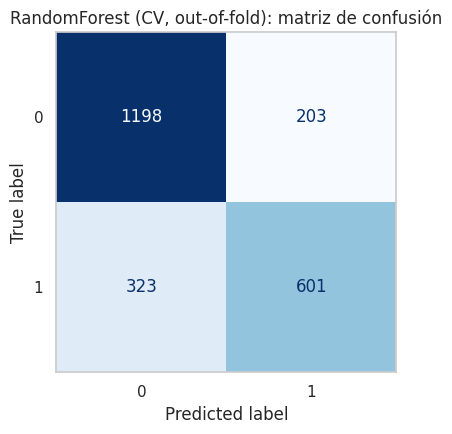

In [13]:
name_rf = "RandomForest"

fig, ax = plt.subplots(figsize=(5, 4.5))
cm_rf = confusion_matrix(y_train, oof_preds[name_rf])
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_rf} (CV, out-of-fold): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

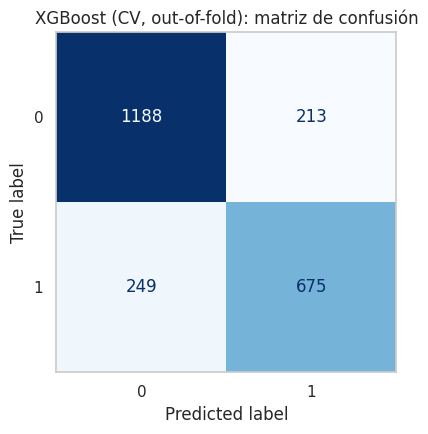

In [14]:
name_xgb = "XGBoost"

fig, ax = plt.subplots(figsize=(5, 4.5))
cm_xgb = confusion_matrix(y_train, oof_preds[name_xgb])
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{name_xgb} (CV, out-of-fold): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

### 3.2 Curva ROC (validación cruzada, predicciones *out-of-fold*)

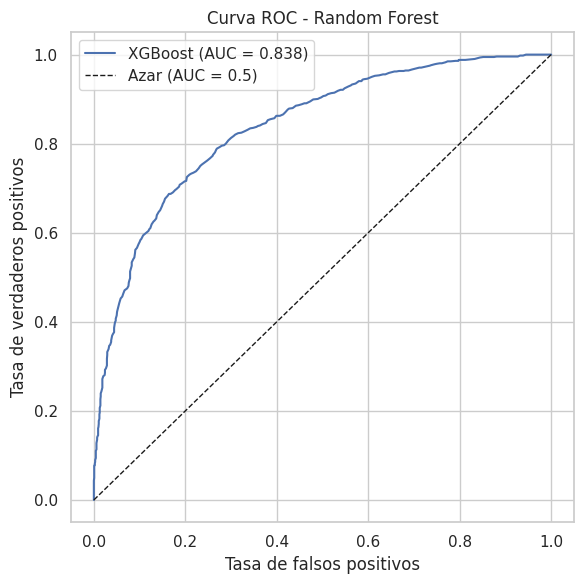

In [15]:
plt.figure(figsize=(6, 6))
fpr, tpr, _ = roc_curve(y_train, oof_probas[name_rf])
auc = roc_auc_score(y_train, oof_probas[name_rf])
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

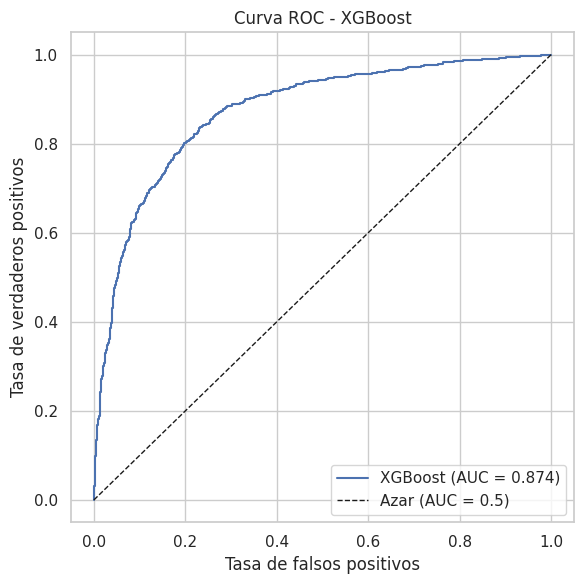

In [16]:
plt.figure(figsize=(6, 6))
fpr, tpr, _ = roc_curve(y_train, oof_probas[name_xgb])
auc = roc_auc_score(y_train, oof_probas[name_xgb])
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Ajuste de hiperparámetros: Random Forest vs XGBoost

Se realiza una búsqueda de hiperparámetros con `RandomizedSearchCV` (más eficiente que un `GridSearchCV` exhaustivo dado el tamaño del espacio de búsqueda), usando el mismo `StratifiedKFold` de 5 particiones sobre el set de entrenamiento y ROC-AUC como métrica objetivo.

### 4.1 Ajuste fino

In [46]:
param_distributions_xgb = {
    "n_estimators": [800, 1500, 2000, 2500, 3000],
    "max_depth": [8, 10],
    "learning_rate": [0.07, 0.08, 0.1],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    "subsample": [0.8],
    "min_child_weight": [3],
    "reg_alpha": [0, 0.02, 0.05, 0.07],
    "reg_lambda": [1.5, 2.5, 3, 3.5],
}
base_estimator_xgb = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")

In [47]:
search_xgb = RandomizedSearchCV(
    estimator=base_estimator_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [48]:
search_xgb.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_xgb.best_score_)
print("Mejores hiperparámetros:")
search_xgb.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC en CV: 0.8788682999216807
Mejores hiperparámetros:


{'subsample': 0.8,
 'reg_lambda': 3,
 'reg_alpha': 0,
 'n_estimators': 2000,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.07,
 'colsample_bytree': 0.6}

In [49]:
tuned_xgb = search_xgb.best_estimator_

In [21]:
param_distributions_rf = {
    "n_estimators": [800, 1000, 1500, 2000, 2500],
    "max_depth": [None],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt", "log2", 0.4, 0.5],
}
base_estimator_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

In [22]:
search_rf = RandomizedSearchCV(
    estimator=base_estimator_rf,
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

In [23]:
search_rf.fit(X_train, y_train)

print("Mejor ROC-AUC en CV:", search_rf.best_score_)
print("Mejores hiperparámetros:")
search_rf.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC en CV: 0.8426729195653071
Mejores hiperparámetros:


{'n_estimators': 2000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [24]:
tuned_rf = search_rf.best_estimator_

In [50]:
searches = {}
searches["XGBoost"] = search_xgb
searches["RandomForest"] = search_rf
tuned_estimators = {"XGBoost": tuned_xgb, "RandomForest": tuned_rf}

In [51]:
param_distributions = {
    "XGBoost": param_distributions_xgb,
    "RandomForest": param_distributions_rf,
}

### 4.2 Comparación de los modelos tuneados (validación cruzada)

Se recalculan las 5 métricas (accuracy, precision, recall, f1, roc_auc) con validación cruzada estratificada de 5 folds sobre el set de entrenamiento, usando en cada caso el mejor estimador encontrado por `RandomizedSearchCV`.

In [52]:
tuned_cv_results = {}
for name, estimator in tuned_estimators.items():
    res = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    tuned_cv_results[name] = res
    print_cv_summary(f"{name} (tuneado)", res)

tuned_cv_summary = {
    name: {
        "Accuracy": res["test_accuracy"].mean(),
        "Precision": res["test_precision"].mean(),
        "Recall": res["test_recall"].mean(),
        "F1": res["test_f1"].mean(),
        "ROC_AUC": res["test_roc_auc"].mean(),
        "ROC_AUC_std": res["test_roc_auc"].std(),
    }
    for name, res in tuned_cv_results.items()
}

--- XGBoost (tuneado) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.8168 +/- 0.0206
Precision: 0.7873 +/- 0.0316
Recall   : 0.7391 +/- 0.0239
F1       : 0.7623 +/- 0.0259
ROC-AUC  : 0.8789 +/- 0.0174
--- RandomForest (tuneado) (CV 5-fold estratificada sobre train) ---
Accuracy : 0.7729 +/- 0.0182
Precision: 0.7481 +/- 0.0318
Recall   : 0.6472 +/- 0.0207
F1       : 0.6938 +/- 0.0231
ROC-AUC  : 0.8427 +/- 0.0240


In [53]:
tuned_cv_summary_df = pd.DataFrame(tuned_cv_summary).T
tuned_cv_summary_df

,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_std
XGBoost,0.816774,0.787316,0.739148,0.762347,0.878868,0.01737
RandomForest,0.772903,0.748147,0.647197,0.693834,0.842673,0.02398


### 4.3 Selección del modelo ganador

In [54]:
best_model_name = tuned_cv_summary_df["ROC_AUC"].idxmax()
tuned_model = tuned_estimators[best_model_name]

print(f"Modelo ganador tras el tuning (según ROC-AUC promedio en CV): {best_model_name}")
tuned_cv_summary_df.loc[[best_model_name]]

Modelo ganador tras el tuning (según ROC-AUC promedio en CV): XGBoost


,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_std
XGBoost,0.816774,0.787316,0.739148,0.762347,0.878868,0.01737


### 4.4 Evaluación del modelo tuneado (set de test)

Primer y único uso del set de test en todo el notebook.

In [56]:
def evaluate(model, X_te, y_te):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds, zero_division=0),
        "Recall": recall_score(y_te, preds, zero_division=0),
        "F1": f1_score(y_te, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_te, proba),
    }

In [57]:
tuned_metrics = evaluate(tuned_model, X_test, y_test)

print(f"Métricas del modelo {best_model_name} tuneado (test):")
for metric_name, value in tuned_metrics.items():
    print(f"  {metric_name:9s}: {value:.4f}")

Métricas del modelo XGBoost tuneado (test):
  Accuracy : 0.8402
  Precision: 0.8317
  Recall   : 0.7489
  F1       : 0.7882
  ROC_AUC  : 0.9117


### 4.5 Matriz de confusión y curva ROC del modelo final (test)

In [58]:
preds_tuned = tuned_model.predict(X_test)
proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

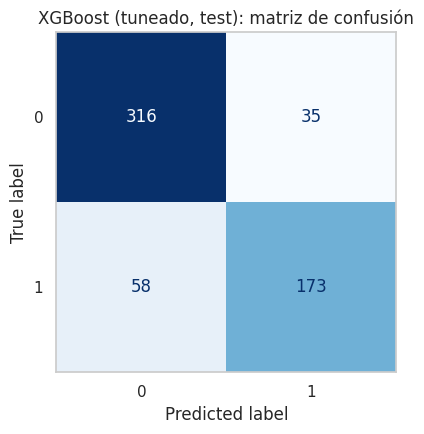

In [59]:
fig, ax = plt.subplots(figsize=(5, 4.5))

cm = confusion_matrix(y_test, preds_tuned)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"{best_model_name} (tuneado, test): matriz de confusión")
ax.grid(False)

plt.tight_layout()
plt.show()

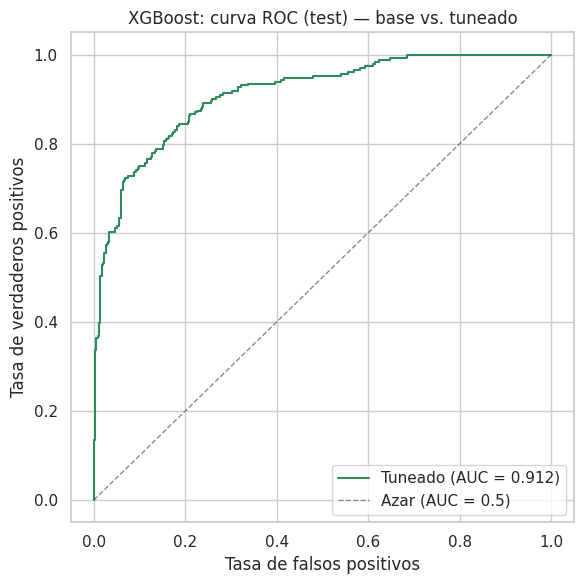

In [60]:
fig, ax = plt.subplots(figsize=(6, 6))

fpr, tpr, _ = roc_curve(y_test, proba_tuned)
auc = roc_auc_score(y_test, proba_tuned)
ax.plot(fpr, tpr, color="seagreen", label=f"Tuneado (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title(f"{best_model_name}: curva ROC (test) — base vs. tuneado")
ax.legend()

plt.tight_layout()
plt.show()

In [61]:
# Guardar el modelo final (opcional)
import joblib
joblib.dump(tuned_model, "modelo_final_ventaja.pkl")
print("Modelo guardado en modelo_final_ventaja.pkl")

Modelo guardado en modelo_final_ventaja.pkl


## 5. Interpretabilidad con SHAP (modelo tuneado)

`feature_importances_` reparte el crédito de forma algo arbitraria cuando hay variables
correlacionadas (recordar la multicolinealidad documentada entre las variables `T*` en
el EDA). SHAP (SHapley Additive exPlanations) da una explicación más consistente:

- Es **aditivo**: la suma de los SHAP values de una fila más el valor base reconstruye
  exactamente el logit (o la probabilidad, según la convención del explainer) de
  `VENTAJA=1` para esa fila.
- Muestra **dirección** del efecto (si un valor alto de la variable empuja la probabilidad
  de `VENTAJA=1` hacia arriba o hacia abajo), no solo cuánto "importa" en promedio.
- Permite explicaciones tanto **globales** (todo el dataset) como **locales** (una
  jugada puntual).

Se usa `TreeExplainer`, que es exacto y eficiente para modelos basados en árboles como
Random Forest y XGBoost. Para clasificación binaria, según la versión de SHAP y del
modelo, el explainer puede devolver los valores para ambas clases; se normaliza para
quedarnos siempre con los SHAP values de la clase positiva (`VENTAJA=1`).

In [62]:
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer(X_test)

# Para clasificación binaria, algunos modelos/backends devuelven un array
# (n_muestras, n_features, n_clases); nos quedamos con la clase positiva (VENTAJA=1).
if shap_values.values.ndim == 3:
    shap_values = shap_values[..., 1]

print("Shape de shap_values.values:", shap_values.values.shape)

Shape de shap_values.values: (582, 20)


### 5.1 Importancia global de variables (SHAP), agrupada por carta/tablero/ronda/turno

In [63]:
sum_abs_shap = pd.Series(np.abs(shap_values.values).sum(axis=0), index=feature_cols)
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=False)
group_shap

,0
Tablero,1968.136108
Carta,1782.021729
Turno,517.239075
Ronda,242.362808


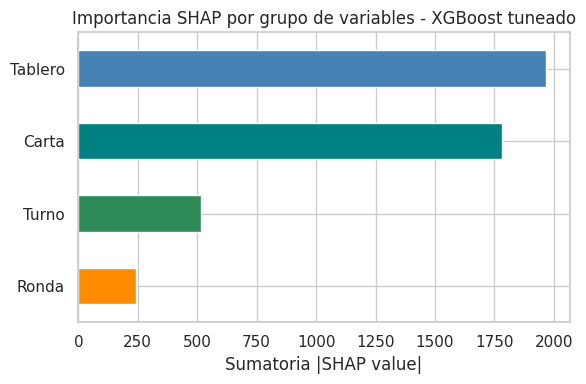

In [64]:
group_shap = sum_abs_shap.groupby(group_map).sum().sort_values(ascending=True)

plt.figure(figsize=(6, 4))
group_shap.plot(kind="barh", color=[group_colors[g] for g in group_shap.index])
plt.title(f"Importancia SHAP por grupo de variables - {best_model_name} tuneado")
plt.xlabel("Sumatoria |SHAP value|")
plt.tight_layout()
plt.show()

In [65]:
sum_abs_shap_sorted = sum_abs_shap.sort_values(ascending=False)
sum_abs_shap_sorted

,0
TURNO,517.239075
T1B,257.353607
T2B,248.088943
C2B,246.900162
T3A,246.146149
RONDA,242.362808
T3C,236.541626
C3B,227.871109
C2A,224.955780
T1C,218.038040


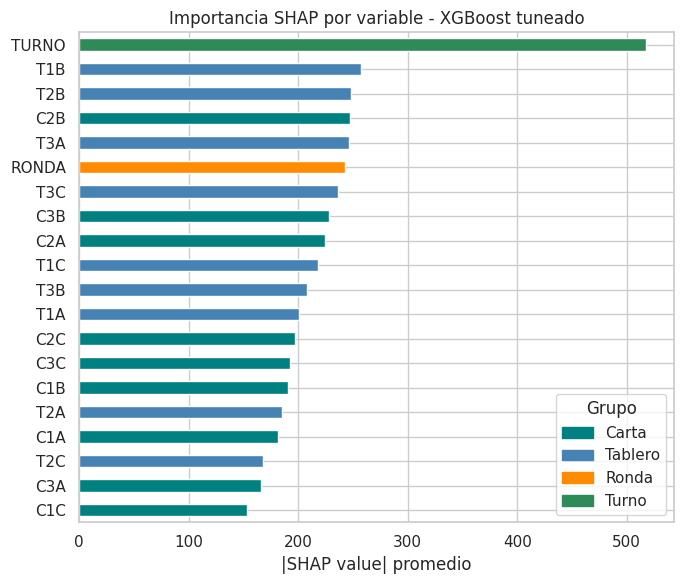

In [66]:
mean_abs_shap_sorted = sum_abs_shap.sort_values(ascending=True)
bar_colors_shap = [group_colors[group_map[var]] for var in mean_abs_shap_sorted.index]

plt.figure(figsize=(7, 6))
mean_abs_shap_sorted.plot(kind="barh", color=bar_colors_shap)
plt.title(f"Importancia SHAP por variable - {best_model_name} tuneado")
plt.xlabel("|SHAP value| promedio")

handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in group_colors.values()]
plt.legend(handles, group_colors.keys(), title="Grupo", loc="lower right")

plt.tight_layout()
plt.show()

### 5.2 Distribución e impacto por variable (SHAP summary plot - beeswarm)

Cada punto es una fila del set de test. La posición en el eje X indica si esa variable
empujó la predicción hacia `VENTAJA=1` o hacia `VENTAJA=0` para esa fila, y el color
indica si el valor de la variable era alto (rojo) o bajo (azul).

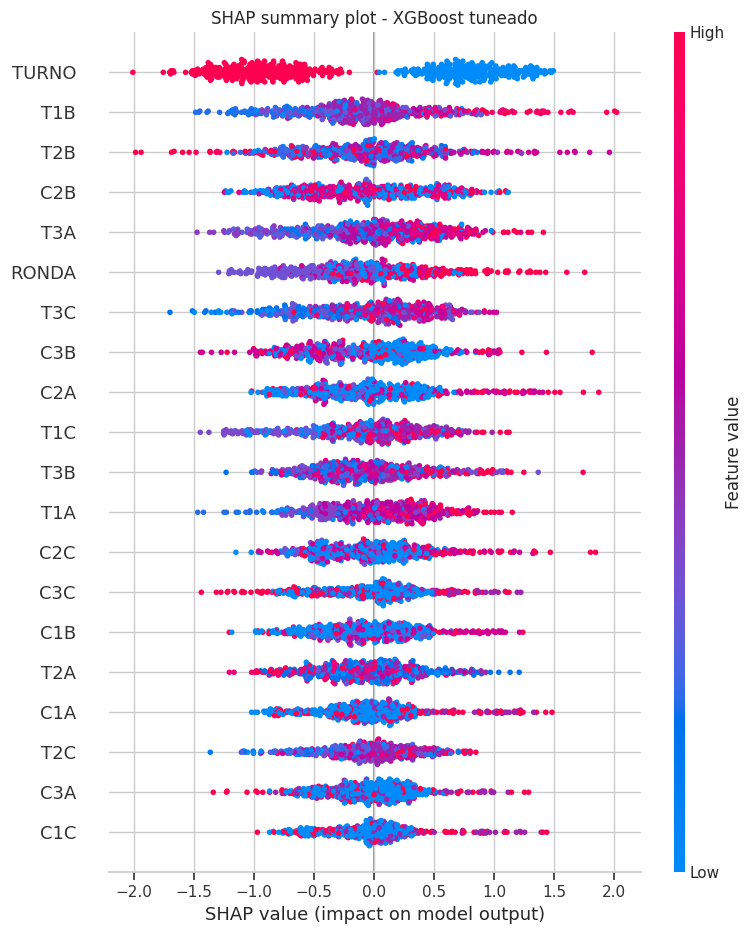

In [67]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP summary plot - {best_model_name} tuneado")
plt.tight_layout()
plt.show()